# Sports Celebrity Classification Model

# Install all the necessary libraries

In [1]:
! pip install pywavelets

  Using cached pywavelets-1.9.0-cp311-cp311-win_amd64.whl.metadata (7.6 kB)
  Using cached numpy-2.4.1-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached pywavelets-1.9.0-cp311-cp311-win_amd64.whl (4.2 MB)
Using cached numpy-2.4.1-cp311-cp311-win_amd64.whl (12.6 MB)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
! python.exe -m pip install --upgrade pip

  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0


In [3]:
! pip install opencv-python

  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)


In [4]:
! pip install seaborn matplotlib pandas numpy scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached pandas-3.0.0-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pillow-12.1.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.0-cp311-cp311-win_amd64.whl.metadata (60

In [6]:
# If we already have requirements.txt file, then do this:
# ! pip install -r requirements.txt

# Import all the necessary libraries and Data Cleaning

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
# First of all, let's do it for one image

In [2]:
# Example: Reading image and displaying its shape
img = cv2.imread('./test_images/sarapowa1.jpg')
img.shape

(225, 225, 3)

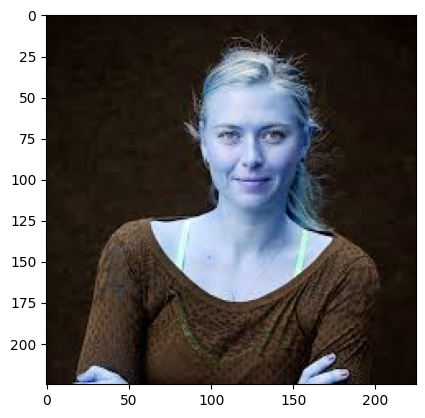

In [3]:
# View image
plt.imshow(img)

In [4]:
# Converting 3d image to gray image (gray value)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(225, 225)

In [5]:
# the gray values are all n-dimensional array with numbers from (0 to 255)
gray

array([[ 4,  4,  5, ...,  5,  5,  3],
       [ 4,  5,  5, ...,  5,  5,  3],
       [ 5,  5,  5, ...,  5,  5,  3],
       ...,
       [12, 13, 13, ...,  9,  9,  7],
       [12, 13, 13, ...,  9,  9,  6],
       [ 8,  9, 10, ...,  7,  7,  8]], shape=(225, 225), dtype=uint8)

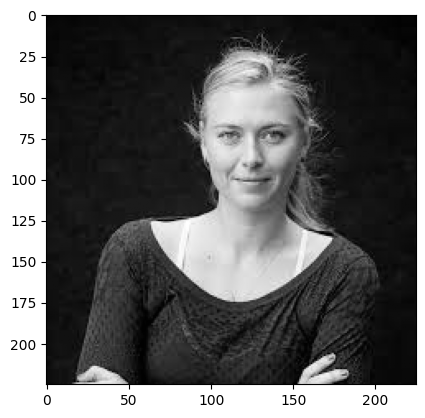

In [6]:
# Displaying the gray image
plt.imshow(gray, cmap='gray')

In [ ]:
# Face Detection using Haar cascade inside opencv documentation

In [7]:
# Loading haarcascades xml files for face and eye
face_cascade = cv2.CascadeClassifier('opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('opencv/haarcascades/haarcascade_eye.xml')

# detect the face and returns the array of (x-coordinate, y-coordinate, width, height), where the face lies exactly in the image
# It would have return two faces (i.e. 2 arrays), if there were two faces in the image
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[89, 46, 71, 71]], dtype=int32)

In [8]:
# Storing the value of faces in (x, y, w, h)
(x, y, w, h) = faces[0]
(x, y, w, h)

(np.int32(89), np.int32(46), np.int32(71), np.int32(71))

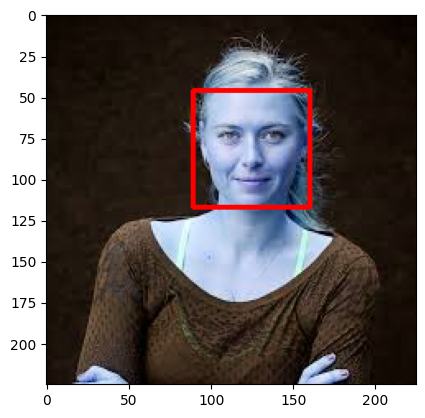

In [9]:
# Now let's draw a rectangle around the face by plotting above values, to check whether haarcascade is detecting the face properly
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

In [10]:
# Detect the eyes
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex,ey), (ex+ew,ey+eh), (0,255,0), 2)

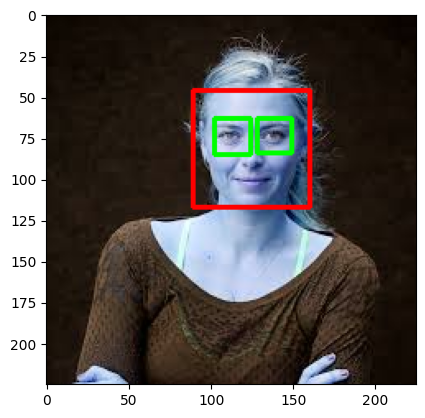

In [11]:
# Display the eyes
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

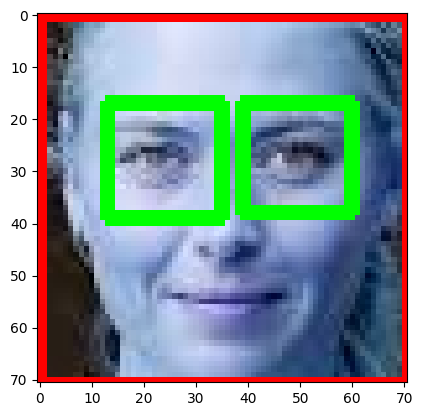

In [12]:
# Display only the cropped face
plt.imshow(roi_color, cmap='gray')

In [16]:
# Function to get the cropped image
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print('Cannot read:', image_path)
        return None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        print('No face detected: ', image_path)
        return None

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) < 2:
            print('Less than 2 eyes: ', image_path)
            return None
        return roi_color

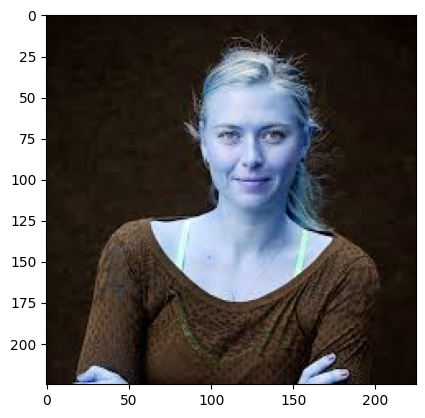

In [17]:
# Testing the function on the same image as above
# First displaying original image
original_image = cv2.imread('./test_images/sarapowa1.jpg')
plt.imshow(original_image)

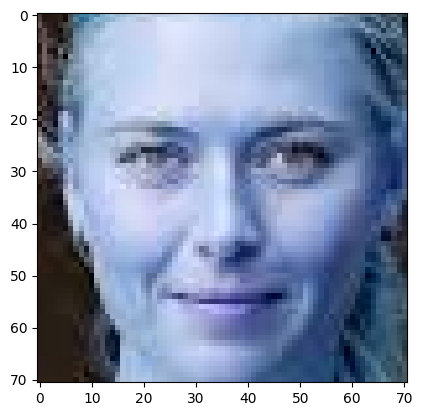

In [18]:
# Displaying the cropped image using function
cropped_image = get_cropped_image_if_2_eyes('./test_images/sarapowa1.jpg')
plt.imshow(cropped_image)

In [19]:
# Setting up the path for the dataset and cropped dataset
path_to_data = './dataset/'
path_to_cr_data = './dataset/cropped/'

In [20]:
import os

img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [21]:
img_dirs

['./dataset/cristiano_ronaldo',
 './dataset/kane_williamson',
 './dataset/kobe_bryant',
 './dataset/lionel_messi',
 './dataset/maria_sharapova',
 './dataset/ms_dhoni',
 './dataset/roger_federer',
 './dataset/serena_williams',
 './dataset/stephen_curry',
 './dataset/virat_kohli']

In [22]:
# Creating the cropped folder inside dataset
import shutil

if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [23]:
# Iterate through each of the image directories

cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    
    celebrity_name = img_dir.split('/')[-1]   # gets only the name from img_dirs (eg. cristiano_ronalo)
    print(celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):
        # if not entry.is_file():
        #     continue

        # if not entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
        #     continue
        
        roi_color = get_cropped_image_if_2_eyes(entry.path)

        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name

            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print('Generating cropped images in folder: ', cropped_folder)

            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name

            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1

cristiano_ronaldo
Generating cropped images in folder:  ./dataset/cropped/cristiano_ronaldo
No face detected:  ./dataset/cristiano_ronaldo\03370000-0aff-0242-cc1b-08daeb3209a7_w1200_r1.jpg
No face detected:  ./dataset/cristiano_ronaldo\1242235904.0.jpg
No face detected:  ./dataset/cristiano_ronaldo\1672718945_ronaldo.jpg
Less than 2 eyes:  ./dataset/cristiano_ronaldo\16799899157309.jpg
No face detected:  ./dataset/cristiano_ronaldo\1791.jpg
No face detected:  ./dataset/cristiano_ronaldo\1_CR7-Al-Nassr.jpg
No face detected:  ./dataset/cristiano_ronaldo\2022-10-27T201618Z_595117998_UP1EIAR1KB5PN_RTRMADP_3_SOCCER-EUROPA-MUN-SHE-REPORT.jpg
Less than 2 eyes:  ./dataset/cristiano_ronaldo\230602093946-01-cristiano-ronaldo-happy-saudi.jpg
Less than 2 eyes:  ./dataset/cristiano_ronaldo\3e25e-16879871569015-1920.jpg
No face detected:  ./dataset/cristiano_ronaldo\800px-C._Ronaldo_-_Ballon_d_27Or_2014.jpg
No face detected:  ./dataset/cristiano_ronaldo\891903860.jpg.jpg
No face detected:  ./dataset

# Feature Engineering

In [24]:
# Import necessary libraries
import numpy as np
import pywt
import cv2

In [25]:
# Function for wavelet transformation
def w2d(img, mode='haar', level=1):
    imArray = img

    # datatype conversion
    
    # convert to grayscale
    imArray = cv2.cvtColor( imArray, cv2.COLOR_RGB2GRAY )

    # convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

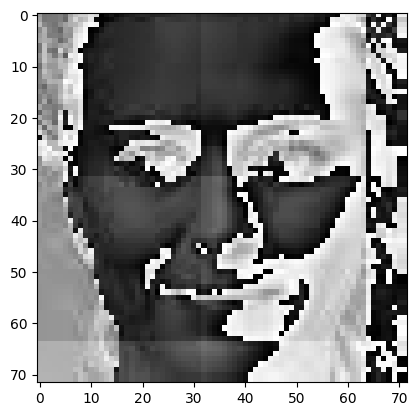

In [26]:
# Testing whether the function works on test image
im_har = w2d(cropped_image, 'db1', 5)
plt.imshow(im_har, cmap='gray')

In [27]:
celebrity_file_names_dict

{'cristiano_ronaldo': ['./dataset/cropped/cristiano_ronaldo/cristiano_ronaldo1.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo2.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo3.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo4.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo5.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo6.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo7.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo8.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo9.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo10.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo11.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo12.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo13.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo14.png',
  './dataset/cropped/cristiano_ronaldo/cristiano_ronaldo15.png',
  './dataset/

In [28]:
# Manually examine cropped folder and delete any unwanted images, retuyrns only the valid files
celebrity_file_names_dict = {}

for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []

    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
        
    celebrity_file_names_dict[celebrity_name] = file_list

celebrity_file_names_dict

{'cristiano_ronaldo': ['./dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo1.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo10.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo100.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo101.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo102.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo103.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo105.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo106.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo107.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo108.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo109.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo11.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo111.png',
  './dataset/cropped/cristiano_ronaldo\\cristiano_ronaldo112.png',
  './dataset/cropped/cristiano_ronaldo\\crist

In [29]:
# Assigning numbers for celebrity name, as categorical variable cannot be used in training
class_dict = {}
count = 0

for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count += 1

class_dict

{'cristiano_ronaldo': 0,
 'kane_williamson': 1,
 'kobe_bryant': 2,
 'lionel_messi': 3,
 'maria_sharapova': 4,
 'ms_dhoni': 5,
 'roger_federer': 6,
 'serena_williams': 7,
 'stephen_curry': 8,
 'virat_kohli': 9}

In [30]:
X, y = [], []

for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        
        # get raw cropped image
        img = cv2.imread(training_image)

        # Scaling raw cropped image to make all the images of same shape and size
        scaled_raw_img = cv2.resize(img, (32, 32))

        # get wavelet transformed images for all images in dataset and scaling
        img_har = w2d(img, 'db1', 4)
        scaled_img_har = cv2.resize(img_har, (32, 32))

        # combining both the images and stacking them vertically
        combined_img = np.vstack((scaled_raw_img.reshape(32*32*3, 1), scaled_img_har.reshape(32*32, 1)))

        # preparing feature and target variable X, y
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [31]:
# Total images inside X
len(X)

430

In [32]:
# size of each image (32*32*3 + 32*32)
len(X[0])

4096

In [33]:
# image in 1st position of X, in array format
X[0]

array([[50],
       [47],
       [47],
       ...,
       [78],
       [50],
       [59]], shape=(4096, 1), dtype=uint8)

In [34]:
# converting image in int type to float type
X = np.array(X).reshape(len(X), 4096).astype(float)
X.shape

(430, 4096)

In [35]:
X.ndim

2

In [36]:
# displaying the floating array format of 1st element of X
X[0]

array([50., 47., 47., ..., 78., 50., 59.], shape=(4096,))

In [37]:
len(y)

430

# <h3>Data cleaning process is done. Now we are ready to train our model</h3>

In [81]:
# We will use SVM with rbf kernel tuned with heuristic finetuning

In [38]:
# import necessary libraries
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [39]:
# Split the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [40]:
# scaling the given X_train data using StandardScaler and creating SVC model with random parameters
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=10))])

# train and evaluate model
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.7407407407407407

In [41]:
len(X_test)

108

In [42]:
print(classification_report(y_test, pipe.predict(X_test), zero_division=0))

              precision    recall  f1-score   support

           0       0.74      0.91      0.82        35
           1       0.00      0.00      0.00         2
           2       1.00      1.00      1.00         2
           3       0.90      0.90      0.90        20
           4       0.27      0.50      0.35         6
           5       0.00      0.00      0.00         5
           6       0.71      0.45      0.56        11
           7       1.00      0.50      0.67         4
           8       1.00      0.40      0.57         5
           9       0.80      0.89      0.84        18

    accuracy                           0.74       108
   macro avg       0.64      0.56      0.57       108
weighted avg       0.73      0.74      0.72       108



In [43]:
# libraries
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [44]:
# Making different candidate models in dictionary for GridSearchCV
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params': {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(solver='lbfgs', max_iter=1000),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [45]:
# Training each model using GridSearchCV
import pandas as pd

scores = []
best_estimators = {}

for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])

    clf = GridSearchCV(pipe, mp['params'], cv=3, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df

,model,best_score,best_params
0,svm,0.689627,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.481395,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.732953,{'logisticregression__C': 1}


In [46]:
best_estimators

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'random_forest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logistic_regression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression', LogisticRegression(C=1, max_iter=1000))])}

In [47]:
best_estimators['svm'].score(X_test, y_test)

0.8425925925925926

In [48]:
best_estimators['random_forest'].score(X_test, y_test)

0.5925925925925926

In [49]:
best_estimators['logistic_regression'].score(X_test, y_test)

0.8148148148148148

In [56]:
svm_best_clf = best_estimators['svm']
lr_best_clf = best_estimators['logistic_regression']

In [63]:
# viewing in confusion matrix array
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, svm_best_clf.predict(X_test))
cm_lr = confusion_matrix(y_test, lr_best_clf.predict(X_test))
print(f'Confusion Matrix for SVM:\n {cm_svm},\n\n Confusion Matrix for Logistic Regression:\n {cm_lr}')

Confusion Matrix for SVM:
 [[32  0  0  1  2  0  0  0  0  0]
 [ 0  1  0  1  0  0  0  0  0  0]
 [ 0  0  2  0  0  0  0  0  0  0]
 [ 1  0  0 19  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 2  0  0  0  0  1  1  0  0  1]
 [ 3  0  0  0  1  0  7  0  0  0]
 [ 0  0  0  0  2  0  0  2  0  0]
 [ 0  0  0  0  1  0  0  0  4  0]
 [ 0  0  0  0  0  1  0  0  0 17]],

 Confusion Matrix for Logistic Regression:
 [[30  0  0  0  2  0  0  0  2  1]
 [ 0  1  0  0  1  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  1  0  0]
 [ 2  0  0 18  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  0  0]
 [ 2  0  0  0  0  1  1  0  0  1]
 [ 4  0  0  0  1  0  6  0  0  0]
 [ 0  0  0  0  2  0  0  2  0  0]
 [ 0  0  0  0  0  0  0  0  5  0]
 [ 0  0  0  0  0  0  0  0  0 18]]


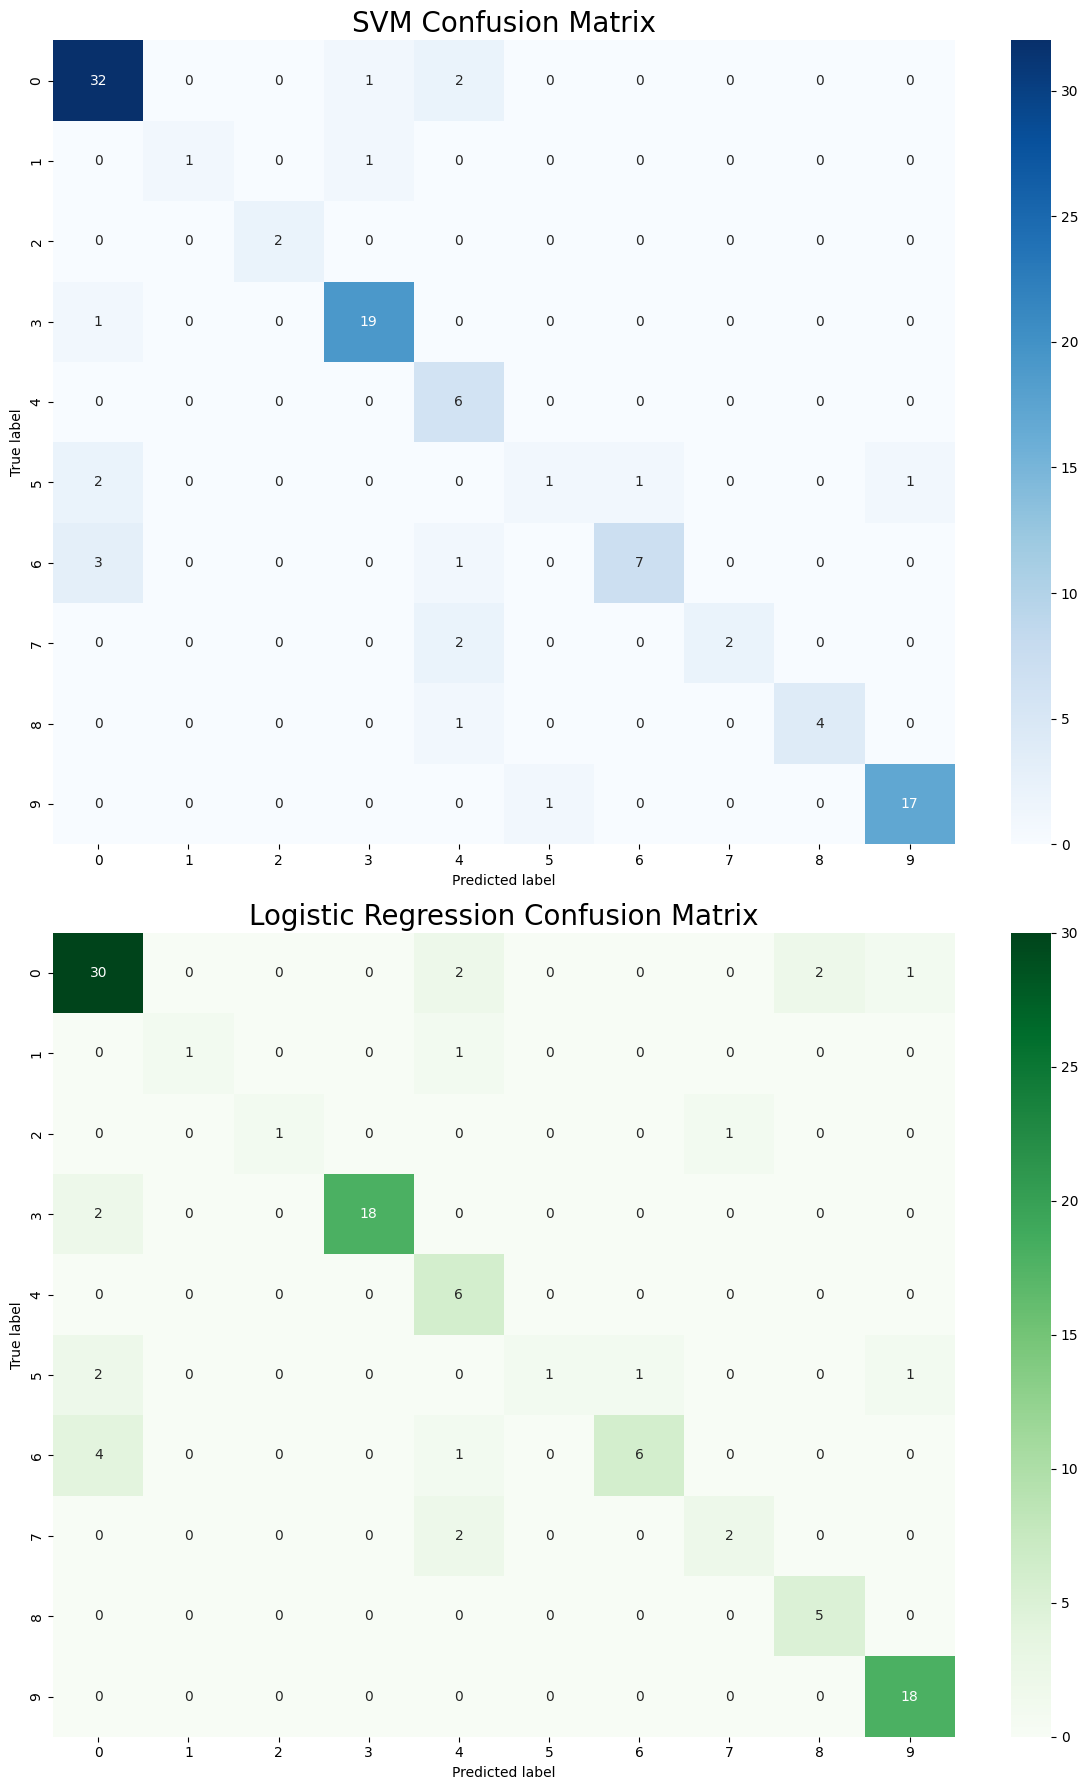

In [75]:
# plotting confusion matrix
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(12,18))

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('SVM Confusion Matrix', fontsize=20)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix', fontsize=20)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

In [76]:
class_dict

{'cristiano_ronaldo': 0,
 'kane_williamson': 1,
 'kobe_bryant': 2,
 'lionel_messi': 3,
 'maria_sharapova': 4,
 'ms_dhoni': 5,
 'roger_federer': 6,
 'serena_williams': 7,
 'stephen_curry': 8,
 'virat_kohli': 9}

# Save the trained model

In [77]:
# install joblib
! pip install joblib

In [78]:
import joblib

# Save the model as a pickle in a file
joblib.dump(svm_best_clf, 'sports_celebrity_model.pkl')

['sports_celebrity_model.pkl']

# Save class dictionary

In [79]:
import json
with open('class_dictionary.json', 'w') as f:
    json.dump(class_dict, f)